In [1]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os
import pandas as pd
import geopandas as gpd
from sedona.spark.stats.clustering.dbscan import dbscan
from sedona.spark.stats.autocorrelation.moran import Moran
from shapely.geometry import Point

In [2]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext
sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/24 22:50:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/24 22:50:34 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/11/24 22:50:34 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/11/24 22:50:34 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/11/24 22:50:34 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/11/24 22:50:34 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, which is already registered.
25/11/24 22:50:34 WARN SimpleFunctionRegistry: The function st_envelop

# Examples

# Negative correlation

In [3]:
import geopandas as gpd

In [4]:
negative_corellation_points = [
    [1, Point(0, 0), 0],
    [2, Point(1, 0), 1],
    [3, Point(2, 0), 0],
    [4, Point(3, 0), 1],

    [5, Point(0, 1), 1],
    [6, Point(1, 1), 0],
    [7, Point(2, 1), 1],
    [8, Point(3, 1), 0],

    [9, Point(0, 2), 0],
    [10, Point(1, 2), 1],
    [11, Point(2, 2), 0],
    [12, Point(3, 2), 1],

    [13, Point(0, 3), 1],
    [14, Point(1, 3), 0],
    [15, Point(2, 3), 1],
    [16, Point(3, 3), 0],
]

In [5]:
negative_corellation_gdf = gpd.GeoDataFrame(negative_corellation_points, columns=["id", "geometry", "value"], geometry="geometry")

<Axes: >

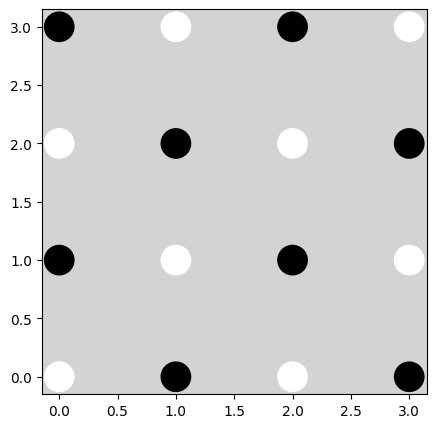

In [6]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

cmap = ListedColormap(["white", "black"])

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("lightgrey")

negative_corellation_gdf.plot(
    column="value",
    cmap=cmap,
    edgecolor="none",  # or "gray" if you want outlines
    ax=ax,
     markersize=490
)

In [7]:
negative_corellation_df = sedona.createDataFrame(negative_corellation_gdf).\
    selectExpr("id", "geometry", "CAST(value AS double) AS value")

In [8]:
from sedona.spark.stats.weighting import add_distance_band_column
from sedona.spark.stats.weighting import add_binary_distance_band_column

negative_correlation_weights = add_binary_distance_band_column(
    dataframe=negative_corellation_df,
    threshold=1.0,
    include_self=False,
)

In [9]:
moran_i_result = Moran.get_global(negative_correlation_weights)

In [10]:
moran_i_result

MoranResult(i=-1.0, p_norm=2.342912171645172e-07, z_norm=-5.169842621131975)

# Positive correlation

In [11]:
positive_corellation_points = [
    [1, Point(0, 0), 1],
    [2, Point(1, 0), 1],
    [3, Point(2, 0), 0],
    [4, Point(3, 0), 0],

    [5, Point(0, 1), 1],
    [6, Point(1, 1), 1],
    [7, Point(2, 1), 0],
    [8, Point(3, 1), 0],

    [9, Point(0, 2), 1],
    [10, Point(1, 2), 1],
    [11, Point(2, 2), 0],
    [12, Point(3, 2), 0],

    [13, Point(0, 3), 1],
    [14, Point(1, 3), 1],
    [15, Point(2, 3), 0],
    [16, Point(3, 3), 0],
]

In [12]:
positive_corellation_gdf = gpd.GeoDataFrame(positive_corellation_points, columns=["id", "geometry", "value"], geometry="geometry")

In [13]:
positive_corellation_df = sedona.createDataFrame(positive_corellation_gdf).\
    selectExpr("id", "geometry", "CAST(value AS double) AS value")

In [14]:
positive_correlation_weights = add_binary_distance_band_column(
    dataframe=positive_corellation_df,
    threshold=1.0,
    include_self=True,
)

<Axes: >

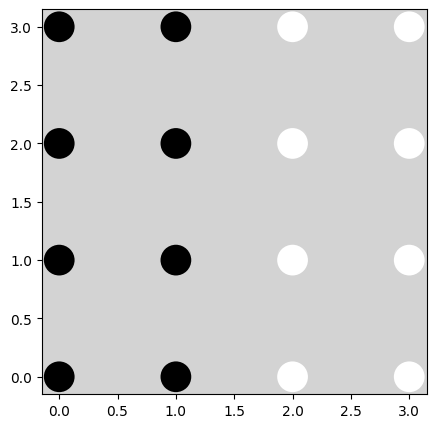

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor("lightgrey")

positive_corellation_gdf.plot(
    column="value",
    cmap=cmap,
    edgecolor="none",  # or "gray" if you want outlines
    ax=ax,
     markersize=490
)

In [16]:
moran_i_result = Moran.get_global(positive_correlation_weights, two_tailed=True)

In [17]:
moran_i_result

MoranResult(i=0.75, p_norm=5.254722590386507e-08, z_norm=5.4424685980921526)

# Weather station example

In [65]:
# you can play with different dates, when you take all of the data the spatial correlation will be poor as we will have duplicated stations with different values
df = sedona.read.format("csv").\
    option("header", "true").\
    load(f"s3a://{bucket_name}/source_data/air_quality_moran").\
    where("Date = '02/04/2024'").\
    selectExpr(
        "monotonically_increasing_id() AS id",
        "ST_MakePoint(CAST(`Site Longitude` AS Double), CAST(`Site Latitude` AS double)) AS geom",
        "`Daily AQI Value` AS value"
    )

In [66]:
from sedona.spark.stats.weighting import add_distance_band_column
from sedona.spark.stats.weighting import add_binary_distance_band_column

In [67]:
weights_df = add_binary_distance_band_column(
    dataframe=df,
    threshold=0.1,
    include_self=True
)

In [68]:
moran_i_result = Moran.get_global(weights_df)

In [69]:
moran_i_result.p_norm
moran_i_result.i
moran_i_result.z_norm

8.111266930445558

In [70]:
moran_i_result

MoranResult(i=0.9339873656365347, p_norm=4.440892098500626e-16, z_norm=8.111266930445558)

In [ ]:
MoranResult(i=0.93, p_norm=0.0, z_norm=8.11)